In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import calendar

# Seasonal Variation in Extremes

From part 1, we were able to see that the summer months tend to have more bottom heavy distributions with fewer, but more extreme extremes. This notebook will explore this variation further through examining the Generalised Extreme Value (GEV) distributions of the data.

First, we will import the data similarly to the first notebook.

In [2]:
df_scot = pd.read_csv('https://www.metoffice.gov.uk/hadobs/hadukp/data/daily/HadSP_daily_totals.txt',
            header = 2,
            sep=r'\s+',
            index_col = 'Date')


# Replace all -99 with nan
df_scot = df_scot.replace(-99.9, np.nan).dropna() 

# Set the index to the date then filter to only include data up to 2024
df_scot.index = pd.to_datetime(df_scot.index)
df_scot = df_scot.loc[:'2025']

df_scot.tail()

,Value
Date,
2025-12-27,0.23
2025-12-28,0.15
2025-12-29,0.30
2025-12-30,0.34
2025-12-31,5.54


In [3]:
# Sample the dataframe by month and select the maximum value for each month
m_max_scot = df_scot.resample('ME').max()

# Group the monthly maximums by month and calculate the mean for each month
max_months_grp_scot = m_max_scot.groupby(m_max_scot.index.month)
mean_months_scot = max_months_grp_scot.mean()

# Create a list of months then add to the dataframe
month_names = [i[:3] for i in list(calendar.month_name)[1:]]
mean_months_scot['Month'] = month_names

mean_months_scot.head()

,Value,Month
Date,,
1,17.638632,Jan
2,14.983053,Feb
3,14.731263,Mar
4,12.704842,Apr
5,13.216211,May


### Separating into seasons

The data is then grouped into seasons by going through each extreme and tagging if it happened during the summer or winnter. For this situation, any month from May to October is marked as summer, and November to April marked as Winter. Care was taken to make sure the yearly data was grouped into the correct year as the Winter data would span across year gaps.

The data is then grouped by season and resampled to find the maximum seasonal daily rainfall of each year.

In [4]:
# Define lists for season and year 
season = []
year_tag = []

# Loop through each value and asssign a season tag and a year tag
for i in m_max_scot.index:
    
    if i.month in [5, 6, 7, 8, 9, 10]:
        season += ['summer']
        year_tag += [i.year]
    else:
        season += ['winter']
        
        if i.month in [11, 12]:
            year_tag += [i.year]
        else:
            year_tag += [i.year-1]

# Add the season and year tags to the dataframe
m_max_scot['season'] = season
m_max_scot['year_tag'] = pd.to_datetime(year_tag, format = '%Y')

m_max_scot.head()

,Value,season,year_tag
Date,,,
1931-01-31,19.17,winter,1930-01-01
1931-02-28,20.06,winter,1930-01-01
1931-03-31,4.85,winter,1930-01-01
1931-04-30,7.55,winter,1930-01-01
1931-05-31,15.53,summer,1931-01-01


In [12]:
# Group the dataframe by season then separate the summer and winter data
s_grp_scot = m_max_scot.groupby('season')

summer_scot = s_grp_scot.get_group('summer')
winter_scot = s_grp_scot.get_group('winter')

# Resample the summer and winter data by year, selecting the maximum value for each year
max_summer_scot2 = summer_scot.resample(on = 'year_tag', rule = 'YE').max().loc[:'2024']
max_winter_scot2 = winter_scot.resample(on = 'year_tag', rule = 'YE').max().loc['1931':'2024']

max_winter_scot2.head()

,Value,season
year_tag,,
1931-12-31,29.22,winter
1932-12-31,28.38,winter
1933-12-31,25.69,winter
1934-12-31,18.51,winter
1935-12-31,24.90,winter


### Plotting

First we will plot the data in a timeseries and then into histograms to examine the seasonal variations.

In [13]:
# Find the overall minimum and maximum for the summer and winter dataframes for plotting on the graph below
max_ovr_summer_scot = max_summer_scot2[max_summer_scot2['Value'] == max_summer_scot2['Value'].max()]
min_ovr_summer_scot = max_summer_scot2[max_summer_scot2['Value'] == max_summer_scot2['Value'].min()]

max_ovr_winter_scot = max_winter_scot2[max_winter_scot2['Value'] == max_winter_scot2['Value'].max()]
min_ovr_winter_scot = max_winter_scot2[max_winter_scot2['Value'] == max_winter_scot2['Value'].min()]

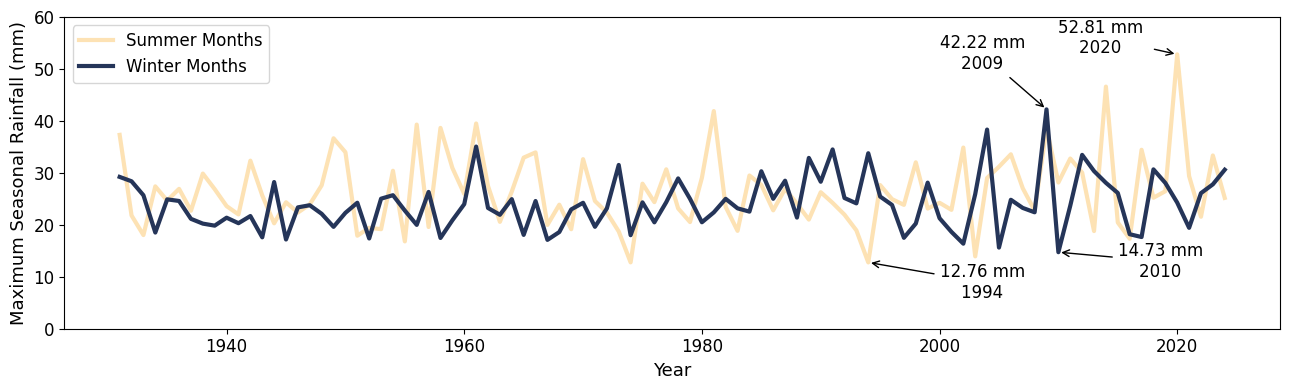

In [17]:
# Create the plotting object then plot the summer and winter timeseries
fig, axes = plt.subplots(1, figsize = (13, 4))

summer = axes.plot(max_summer_scot2.index.year, max_summer_scot2['Value'], linewidth = 3, 
                   label = 'Summer Months', color = '#FDE2B4')

winter = axes.plot(max_winter_scot2.index.year, max_winter_scot2['Value'], linewidth = 3, 
                   label = 'Winter Months', color = '#253559')

# Annotate the maximum and minimum points for the summer and winter dataframes
axes.annotate(str(max_ovr_summer_scot['Value'].iloc[0]) + ' mm \n    ' + str(max_ovr_summer_scot.index.year[0]),
              (max_ovr_summer_scot.index.year[0], max_ovr_summer_scot['Value'].iloc[0]),
              arrowprops = dict(arrowstyle =  '->'), xytext=(2010, 53), fontsize = 12)

axes.annotate(str(min_ovr_summer_scot['Value'].iloc[0]) + ' mm\n    ' + str(min_ovr_summer_scot.index.year[0]),
              (min_ovr_summer_scot.index.year[0], min_ovr_summer_scot['Value'].iloc[0]),
              arrowprops = dict(arrowstyle =  '->'), xytext=(2000, 6), fontsize = 12)

axes.annotate(str(max_ovr_winter_scot['Value'].iloc[0]) + ' mm\n    ' + str(max_ovr_winter_scot.index.year[0]),
              (max_ovr_winter_scot.index.year[0], max_ovr_winter_scot['Value'].iloc[0]),
              arrowprops = dict(arrowstyle =  '->'), xytext=(2000,50), fontsize = 12)

axes.annotate(str(min_ovr_winter_scot['Value'].iloc[0]) + ' mm\n    ' + str(min_ovr_winter_scot.index.year[0]),
              (min_ovr_winter_scot.index.year[0], min_ovr_winter_scot['Value'].iloc[0]),
              arrowprops = dict(arrowstyle =  '->'), xytext=(2015,10), fontsize = 12)

# Label and clean up the axes
axes.set_xlabel('Year', fontsize = 13)
axes.set_ylabel('Maximum Seasonal Rainfall (mm)', fontsize = 13)

axes.set_xticks(np.arange(1940, 2040, 20))
axes.set_xticklabels(np.arange(1940, 2040, 20), fontsize=12)

axes.set_yticks(np.arange(0, 61, 10))
axes.set_yticklabels(np.arange(0, 61, 10), fontsize=12)

axes.legend(loc = 2, fontsize = 12)
axes.set_ylim(0, 60)

plt.tight_layout()

# plt.savefig('summwinttime.pdf', bbox_inches = 'tight')
plt.savefig('summwinttime.png', bbox_inches = 'tight')

plt.show()

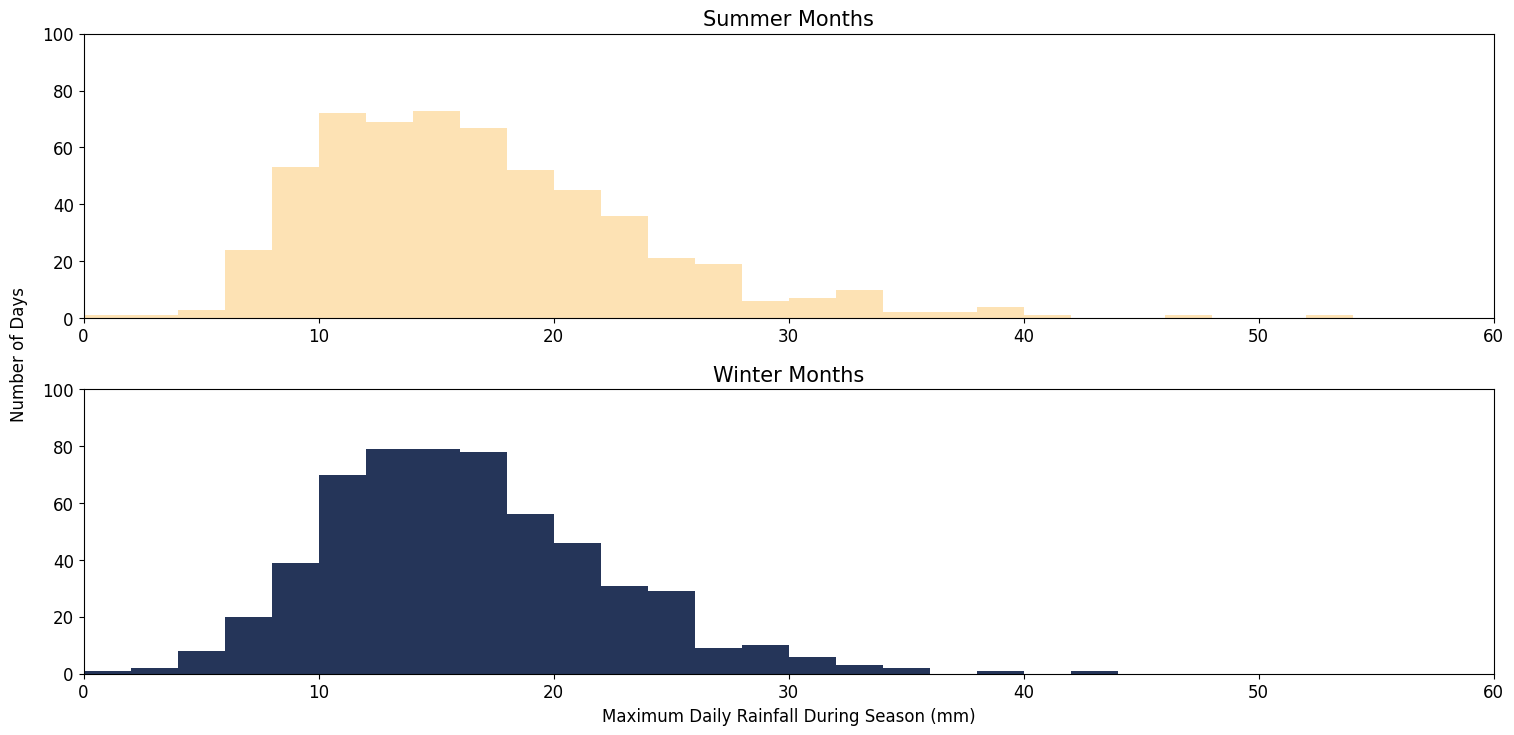

In [46]:
fig, axes = plt.subplots(2, figsize = (15, 8), sharey=True)

axes[0].hist(summer_scot['Value'], bins = 30, label = 'summer', color = '#FDE2B4', range = (0, 60))
# axes[0].legend()
axes[0].set_title('Summer Months', fontsize = 15)
# axes[0].set_xlabel('Maximum Monthly Rainfall (mm)')

axes[0].set_xlim(0, 60)
axes[0].set_ylim(0, 80)

axes[1].hist(winter_scot['Value'], bins = 30, label = 'winter', color = '#253559', range = (0, 60))
# axes[1].legend()
axes[1].set_title('Winter Months', fontsize = 15)
axes[1].set_xlabel('Maximum Daily Rainfall During Season (mm)', fontsize = 12)

axes[1].set_xlim(0, 60)
axes[1].set_ylim(0, 80)

for ax in axes:    
    
    ax.set_xticks(np.arange(0, 61, 10))
    ax.set_xticklabels(np.arange(0, 61, 10), fontsize=12)

    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels(np.arange(0, 101, 20), fontsize=12)

fig.text(0.001, 0.5, 'Number of Days', va='center', rotation='vertical', fontsize = 12)


# plt.tight_layout()

plt.subplots_adjust(left=0.05, bottom=0.1, right=0.99, top=0.9, wspace=0.1, hspace=0.25)

# plt.savefig('summwinthist.pdf', bbox_inches='tight')

plt.show()